## Imports
This can take awhile. Upwards of 3 minutes on an A100 Node

NOTE: Do not "run all". I've observed a consistent crash if you run past the cell defining the policy. Run until that cell, and then you can choose which evaluation you want to do.

In [1]:
import math
import os
import pathlib
import sys
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = ".15"

import numpy as np
import mediapy as media

from libero.libero import benchmark, get_libero_path
from libero.libero.envs import OffScreenRenderEnv

from openpi.policies import policy_config as _policy_config
from openpi.shared import download
from openpi.training import config as _config

sys.path.append('../py_script')
import profiling as prof
prof.prof_start()

[robosuite WARNING] No private macro file found! (__init__.py:7)
[robosuite WARNING] It is recommended to use a private macro file (__init__.py:8)
[robosuite WARNING] To setup, run: python /home/hppeng/workspace/mujoco_test/mujoco_playground/.venv/lib/python3.12/site-packages/robosuite/scripts/setup_macros.py (__init__.py:9)
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyPacked has no __module__ attribute
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyObject has no __module__ attribute


## Setup R4B

R4B VLM with state of the art performance, at least among open small models.
https://huggingface.co/YannQi/R-4B

In [2]:
from PIL import Image
import torch
from transformers import AutoModel, AutoProcessor

model_path = "YannQi/R-4B"

# Load model
model = AutoModel.from_pretrained(
    model_path,
    torch_dtype=torch.float32,
    trust_remote_code=True,
).to("cuda")

# Load processor
processor = AutoProcessor.from_pretrained(model_path, trust_remote_code=True)

Using MultiModalProjector_withLayerNorm


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


In [3]:
from llm_apis.tool_api import TransformersToolHandler, tool_wrap
from llm_apis.agent_responses import ImageResponse

def chat(user_message):
    tool_handler.add_message(user_message)
    return tool_handler.tool_chat()
tool_handler = TransformersToolHandler(model, processor)

In [2]:
def _quat2axisangle(quat):
    """
    Copied from robosuite: https://github.com/ARISE-Initiative/robosuite/blob/eafb81f54ffc104f905ee48a16bb15f059176ad3/robosuite/utils/transform_utils.py#L490C1-L512C55
    """
    # clip quaternion
    if quat[3] > 1.0:
        quat[3] = 1.0
    elif quat[3] < -1.0:
        quat[3] = -1.0

    den = np.sqrt(1.0 - quat[3] * quat[3])
    if math.isclose(den, 0.0):
        # This is (close to) a zero degree rotation, immediately return
        return np.zeros(3)

    return (quat[:3] * 2.0 * math.acos(quat[3])) / den

## Controller and environment definition

EE position (libero dataset).

In [12]:
# Load pi model
def create_pi05(model_name, checkpoint_dir=None, assets_dir=None):
    vla_config = _config.get_config(model_name)
    if checkpoint_dir is None:
        checkpoint_dir = download.maybe_download(f"gs://openpi-assets/checkpoints/{model_name}")
    else:
        checkpoint_dir = pathlib.Path(checkpoint_dir).resolve()

    # Load norm stats from assets dir if checkpoint doesn't have them
    norm_stats = None
    if assets_dir is not None:
        data_config = vla_config.data.create(vla_config.assets_dirs, vla_config.model)
        if data_config.asset_id is not None:
            from openpi.training import checkpoints as _checkpoints
            assets_path = pathlib.Path(assets_dir).resolve()
            norm_stats = _checkpoints.load_norm_stats(assets_path, data_config.asset_id)

    policy = _policy_config.create_trained_policy(
        vla_config,
        checkpoint_dir,
        norm_stats=norm_stats
    )
    return policy

def prompt_from_obs(obs, task, scene_plan=''):
    """Build observation dict for Pi0Fuse inference.

    The thought prefix must match the training format from cot_simple.json:
      "Instruction: <task>\\n<scene_plan>"
    A 1-element thought list triggers action-mode tokenization (BEGIN_OF_ACTION
    suffix), which prefill() strips before deciding to think or act.
    """
    state_vec = np.concatenate(
        (
            obs["robot0_eef_pos"],
            _quat2axisangle(obs["robot0_eef_quat"]),
            obs["robot0_gripper_qpos"],
        )
    )
    # Align the initial prefix with cot_simple.json's "content" template.
    if scene_plan:
        if scene_plan.lstrip().startswith("Instruction:"):
            thought_prefix = scene_plan
        else:
            thought_prefix = 'Instruction: ' + task + '. \n' + scene_plan
    else:
        thought_prefix = (
            'Instruction: ' + task + '. \n'
            'Plan: TBD.\n'
            ' What I have done: TBD.\n'
            'Now I need to do: TBD.\n'
        )
    return {
        'observation/image': obs['agentview_image'][::-1, ::-1, :],
        'observation/wrist_image': obs['robot0_eye_in_hand_image'][::-1, ::-1, :],
        "observation/state": state_vec,
        #"state": state_vec,  # required by LiberoReasonInputs
        'prompt': task,
        'thought': [thought_prefix],
    }

In [7]:
# Create a trained policy.
policy = create_pi05(   # Use LoRA weights:
    'pi05_libero_reason_lora',
    # checkpoint_dir='pace/openpi/checkpoints/pi05_libero_reason_lora/pi05_libero_reason_lora/9999',
    checkpoint_dir='../pace/openpi/checkpoints/pi05_libero_reason_lora/pi05_libero_reason_lora/30000',
    assets_dir='../pace/openpi/assets/pi05_libero_reason_lora'
)
policy_infer = prof.profiled(policy.infer, name="infer")
# NOTE: DO NOT RUN PAST THIS CELL WHEN STARTING UP! IT CAUSES A ASYNCIO CRASH FOR SOME REASON

/home/hppeng/workspace/mujoco_test/mujoco_playground/.venv/lib/python3.12/site-packages/jax/extend/linear_util.py:38: DeprecationWarning: linear_util.wrap_init is missing a DebugInfo object. This behavior is deprecated, use api_util.debug_info() to construct a proper DebugInfo object and propagate it to this function. See https://github.com/jax-ml/jax/issues/26480 for more details.
  debug_info = debug_info or _missing_debug_info("linear_util.wrap_init")
/home/hppeng/workspace/mujoco_test/mujoco_playground/.venv/lib/python3.12/site-packages/jax/extend/linear_util.py:38: DeprecationWarning: linear_util.wrap_init is missing a DebugInfo object. This behavior is deprecated, use api_util.debug_info() to construct a proper DebugInfo object and propagate it to this function. See https://github.com/jax-ml/jax/issues/26480 for more details.
  debug_info = debug_info or _missing_debug_info("linear_util.wrap_init")
/home/hppeng/workspace/mujoco_test/mujoco_playground/.venv/lib/python3.12/site-pac

In [56]:
def _get_libero_env(task, resolution, seed):
    """Initializes and returns the LIBERO environment, along with the task description."""
    task_description = task.language
    task_bddl_file = pathlib.Path(get_libero_path("bddl_files")) / task.problem_folder / task.bddl_file
    env_args = {"bddl_file_name": task_bddl_file, "camera_heights": resolution, "camera_widths": resolution, "camera_depths": True}
    env = OffScreenRenderEnv(**env_args)
    env.seed(seed)  # IMPORTANT: seed seems to affect object positions even when using fixed initial state
    return env, task_description

class LiberoEnvMaker:
    def __init__(self, suite: str,
                 render_resolution: int = 512, seed: int = 0,
                 repeats: int = 1):
        benchmark_dict = benchmark.get_benchmark_dict()
        self.task_suite = benchmark_dict[suite]()
        self.repeats = repeats
        self.render_resolution = render_resolution
        self.seed = seed

    def get_num_tasks(self):
        return self.task_suite.n_tasks

    def task_instantiations(self, task_id):
        task = self.task_suite.get_task(task_id)
        initial_states = self.task_suite.get_task_init_states(task_id)
        env, task_description = _get_libero_env(task, self.render_resolution, self.seed)
        for episode_idx in range(self.repeats):
            env.reset()
            obs = env.set_init_state(initial_states[episode_idx])
            yield obs, env, task_description

libero_envs = LiberoEnvMaker('libero_90')

# STOP HERE WHEN RUNNING AND WAIT FOR ABOVE CELL TO FINISH!

### Define data structures for collecting outputs

Run this cell to clear collected data buffers.

In [80]:
rollout = []
frames = []
wrist_frames = []
snapshots = []
statuses = []
subtasks = []

### Collect output and video for one run.

Don't run this if you want to run the VLM verification things.

Subtask: Plan: 1. Push the drawer to close it. What I have done: Nothing. Now I need to do: Push the drawer to close it.
Subtask: Plan: 1. Push the drawer to close it. What I have done: 1. Push the drawer to close it. Now I need to do: Nothing. Task complete.
Subtask: Plan: 1. Push the drawer to close it. What I have done: 1. Push the drawer to close it. Now I need to do: Nothing. Task complete.
Subtask: Plan: 1. Push the drawer to close it. What I have done: 1. Push the drawer to close it. Now I need to do: Nothing. Task complete.
Subtask: Plan: 1. Push the drawer to close it. What I have done: 1. Push the drawer to close it. Now I need to do: Nothing. Task complete.
Subtask: Plan: 1. Push the drawer to close it. What I have done: 1. Push the drawer to close it. Now I need to do: Nothing. Task complete.
Subtask: Plan: 1. Push the drawer to close it. What I have done: 1. Push the drawer to close it. Now I need to do: Nothing. Task complete.
Subtask: Plan: 1. Push the drawer to close it

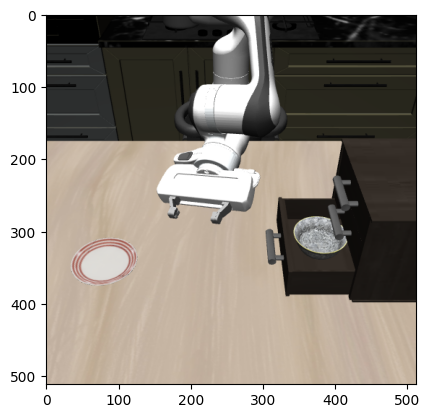

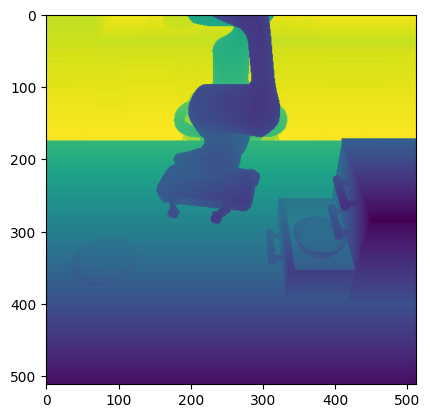

In [84]:
def get_cam_pose(env, cam_name="agentview"):
    cam_id = env.sim.model.camera_name2id(cam_name)
    return (env.sim.model.cam_pos[cam_id], env.sim.model.cam_quat[cam_id])
    
def set_cam_pose(env, pose, cam_name="agentview"):
    cam_id = env.sim.model.camera_name2id(cam_name)
    env.sim.model.cam_pos[cam_id] = pose[0]
    env.sim.model.cam_quat[cam_id] = pose[1]

for instance in libero_envs.task_instantiations(10):
    #obs, env, task_description = instance
    task_description = "Close the drawer"
    #task_description = "Open the top drawer."
    #task_description = 'Pick up the cookie box.'
    # prev_pos, prev_quat = save_cam_pose
    # set_cam_pose(env, (prev_pos+[0, 0, 1], prev_quat))
    # obs, reward, done, info = env.step(np.zeros(7))
    # break
    #scene_plan = 'Plan: 1. Pick up the cookie box. What have I done: 1. Pick up the cookie box. Now I need to do: Nothing. Task complete.'
    scene_plan = ''
    #scene_plan = 'Plan: 1. Open the top drawer. \
#What have I done: Open the top drawer. \
#Now I need to do: Nothing. Task complete.'
    prompt = prompt_from_obs(obs, task_description, scene_plan)
    vla_output = policy.infer(prompt)
    actions = vla_output['actions']
    subtask = vla_output.get('subtask', None)
    if subtask is not None:
        print("Subtask:", subtask)
        scene_plan = subtask
    rollout.append(obs)

    trajectory_idx = 0
    for i in range(200):
        act = np.copy(actions[trajectory_idx])
        act[-1] *= 1
        obs, reward, done, info = env.step(act)
        rollout.append(obs)
        frames.append(obs['agentview_image'][::-1, ::-1, :])
        wrist_frames.append(obs['robot0_eye_in_hand_image'][::-1, ::-1, :])
        trajectory_idx += 1
        if trajectory_idx == (len(actions)//2):
            prompt = prompt_from_obs(obs, task_description, scene_plan)
            vla_output = policy_infer(prompt)
            actions = vla_output['actions']
            subtask = vla_output.get('subtask', None)
            if subtask is not None:
                print("Subtask:", subtask)
                scene_plan = subtask
            trajectory_idx = 0

freq = 20
#save_cam_pose = get_cam_pose(env)
print(task_description)
img = obs['agentview_image'][::-1, ::-1, :]
import matplotlib.pyplot as plt
plt.figure(0)
plt.clf()
plt.imshow(img)
plt.figure(1)
plt.clf()
plt.imshow(obs['agentview_depth'][::-1, ::-1, :])
plt.show()
media.write_video(f'franka_90.mp4', frames, fps=freq)
media.write_video(f'franka_90_wrist.mp4', wrist_frames, fps=freq)
media.write_video(f'franka_libero.mp4', frames, fps=freq)
media.write_video(f'franka_libero_wrist.mp4', wrist_frames, fps=freq)

In [ ]:
print('\n'.join(obs.keys()))
print(obs['object-state'].shape)
print(obs['akita_black_bowl_1_to_robot0_eef_pos'])
print(obs['object-state'].reshape((-1, 7))[:, :3])

depth = rollout[0]['agentview_depth'][::-1, ::-1, :]
print(depth.shape)
media.write_image('../franka_libero_init.png', frames[0])
np.save('../franka_libero_init_depth.npy', depth)

### Running with VLM verification in the loop

Not exactly like Verytrace.
The outer loop (plan loop) is being handled completely by one instance of Gemma3, which is making a tool call to command the VLA to take an action (`execute_action` function.).
The planner VLM is also told to explain its plan through the arguments to the function.
The simulator runs for a fixed number of steps, then the verifier VLM is given the function arguments and final robot state (as an image).
The verifier checks if the intent is reflected in the image, and returns the result (SUCCESS, IN_PROGRESS, or FAILURE) to the planner.

This first cell can take a long time to run, since it jit compiles the inference function.

In [16]:
import textwrap

obs = None
observed_image = None
env = None

@prof.profiled
def env_step(actions):
    return env.step(actions)

@tool_wrap(ImageResponse)
def get_robot_image() -> ImageResponse:
    """
    Get the image the robot is currently seeing.
    Use this at the start of a task, to understand what the camera sees.
    """
    return observed_image

from llm_apis import transformers_api
import importlib
import llm_apis
importlib.reload(llm_apis.llm_tool)
from llm_apis.llm_tool import TransformersTool, json_output
import json
verifier_prompt = """
You are a careful AI assistant auditing a robot. The robot was told to perform a series of actions,
but it is error prone. One action in this series is shown to you, intended to complete a subtask.
Your job is to decide if the action was successfully executed or not.

You should return a json string, of the form:

```json
{
  "status": ["OK"|"IN_PROGRESS"|"FAILURE"],
  "reason": "put reasoning here"
}
```

Status should be:
 - OK if the execution succeeded fully.
 - IN_PROGRESS if it looks like the execution is on track to succeed.
   For example, if the subtask is to pick up an object and the robot is near the object but not grasped yet.
 - FAILURE if the subtask failed, for example the robot picked up the wrong object.

Think in Chinese, but output results in English.

"""
@json_output
def _verify(before, after, action, postcondition):
    return [transformers_api.make_message(
        texts=[
            "These two images represent the before and after of trying to execute an action.",
            f"The action was: {action}, the subgoal is: {postcondition}"
        ],
        images=[before, after]
    )]
_verify.system_prompt = verifier_prompt
verify = TransformersTool(_verify, model, processor)

#@tool_wrap(ImageResponse)
def execute_action(action: str, postcondition: str) -> ImageResponse:
    """
    Attempt to execute a short action from the robot.

    Arguments:
        action: The action to execute. This should be a short, "single step" action.
        postcondition: Condition to be satisfied at the end of this action. For example, "robot is holding cup"

    Return: New image of the scene after robot has attempted action execution, along with status message (sucess or failure)
    """
    global obs, observed_image
    
    prompt = prompt_from_obs(obs, action)
    vla_output = policy.infer(prompt)
    actions = vla_output['actions']
    #print(vla_output.get('subtask', 'no subtask output'), flush=True)

    before_image = obs['agentview_image'][::-1, ::-1, :]
    trajectory_idx = 0
    for i in range(100):
        act = np.copy(actions[trajectory_idx])
        act[-1] *= 1
        obs, reward, done, info = env_step(act)
        prompt = prompt_from_obs(obs, action)
        rollout.append(prompt['observation/state'])
        frames.append(obs['agentview_image'][::-1, ::-1, :])
        wrist_frames.append(obs['robot0_eye_in_hand_image'][::-1, ::-1, :])
        trajectory_idx += 1
        if trajectory_idx == (len(actions)//2):
            vla_output = policy_infer(prompt)
            actions = vla_output['actions']
            #print(vla_output.get('subtask', 'no subtask output'), flush=True)
            trajectory_idx = 0
    observed_image = frames[-1]
    snapshots.append(observed_image)
    try:
        json_data = verify(before_image, observed_image, action, postcondition)
    except json.JSONDecodeError as e:
        import traceback
        traceback.print_exc()
        json_data = {'status': 'FAILURE', 'reason': f'Verifier Error: {repr(e)}'}
    msg = json.dumps(json_data, indent=2)
    print(msg)
    statuses.append(msg)
    subtasks.append((action, postcondition))
    return ImageResponse(img=observed_image, message=msg)

tool_handler.register(get_robot_image)
tool_handler.register(execute_action)

llm_prompt = """
You are a careful AI assistant controlling a robot using natural language.
You have control over a rudimentary low-level controller that can be comamnded by short natural language commands.
When given a task, you should break it down into steps, and use `execute_action` to execute the steps one by one,
checking that the execution succeeded by reading its return output. For example, a task of "placing A on B" might be
broken up into "pick up A" and "place A on B".

If the execution did not succeed, try to interpret the error message given. Sometimes, you may just need to
execute the same task again (for longer tasks); sometimes you may need to try a different approach.
For example, if the robot picked up the wrong object, you may have to tell it to put down the object it's holding
before picking up the correct object. Or, you can try identifying the object in different ways, such as by position, size,
or color.

If you get an IN_PROGRESS status, you should reissue the same command, until a success or failure status is read.
If the episode terminated, don't try to restart it. Just tell the user you couldn't complete the task and terminate.

When you are done with the task, give a status report of this form:

```json
{
  "status": ["OK"|"IN_PROGRESS"|"FAILURE"],
  "reason": "put reasoning here"
}
```

All thinking MUST be in Chinese.
Perform all thinking in Chinese.
Only arguments to tool calls and final output can be in English.
"""

### Manually running the "verified" loop

Pretty easy, LLM handles tool calling.
Next cell is result visualization

In [ ]:
tool_handler.reset_chat(llm_prompt)
task = "Describe the scene the robot sees."
s = chat(task)
print("Final output:", s)

In [ ]:
import matplotlib.pyplot as plt
print(s)
idx = 0
plt.figure(0)
plt.clf()
plt.imshow(snapshots[idx])
print(statuses[idx])
print(subtasks[idx])

### Run multiple trials and save the results

Result videos, and observations/verifier and planner traces in a pickle file

In [11]:
import pickle

def run_one_trial(trial_idx):
    global env
    global obs, observed_image
    global rollout, frames, wrist_frames, snapshots, statuses, subtasks
    rollout = []
    frames = []
    wrist_frames = []
    snapshots = []
    statuses = []
    subtasks = []

    # TODO: iterate through both levels
    for instance in libero_envs.task_instantiations(trial_idx):
        obs, env, task_description = instance
        break
    observed_image = obs['agentview_image'][::-1, ::-1, :]
    tool_handler.reset_chat(llm_prompt)
    s = chat(f"Please {task_description}.")
    frames.append(observed_image)
    wrist_frames.append(obs['robot0_eye_in_hand_image'][::-1, ::-1, :])

    with open(f"output/franka_libero_90.{trial_idx}.pkl", "wb") as outfile:
        pickle.dump({
            "snapshots": snapshots,
            "statuses": statuses,
            "subtasks": subtasks,
            "state_traj": rollout
        }, outfile)
    media.write_video(f'output/franka_libero_90.{trial_idx}.mp4', frames, fps=20)
    media.write_video(f'output/franka_libero_90_wrist.{trial_idx}.mp4', wrist_frames, fps=20)

In [17]:
import time
t0 = time.monotonic()
for i in range(1, 2):
    print(f"Running trial {i}")
    run_one_trial(i)
t1 = time.monotonic()
print("Time elapsed:", t1 - t0)

Running trial 1


Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.


At each turn, if you decide to invoke any of the function(s), it should be wrapped with ```tool_code```.
The python methods described below are imported and available, you can only use defined methods.
The generated code should be readable and efficient. The response to a method will be wrapped in
```tool_output```; use it to call more tools or generate a helpful, friendly response.
For example, if the function `echo` is defined, you can use it as follows:

```tool_code
echo("testing!")
```

DO NOT ASSIGN VARIABLES! Outputs from called functions will be fed back to you as JSON and image data directly.
You may only call one function at a time. Attempting to call multiple functions or adding comments to
the function call will result in an error.

Function calls cannot be used in thinking mode. You cannot call functions in think mode. Finish thinking
before calling any functions.

The following Python functions are available:

```python
def get_robot_image() -> ImageResponse:
    """
    

Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.



------> Matched valid tool call

用户现在需要完成的任务是拿起旁边的黑色碗，然后放在盘子上。首先得先获取当前机器人看到的图像，了解周围环境。所以第一步应该调用get_robot_image()来获取当前视角的图像，这样才能确定黑色碗和盘子的位置。

首先，思考过程：要完成这个任务，首先需要知道当前场景中黑色碗和盘子的位置，所以先调用get_robot_image()，获取图像信息，之后才能基于图像判断位置。然后执行拿起黑色碗的动作，再执行放在盘子上的动作。但第一步必须先获取图像，所以先调用get_robot_image()。

现在看提供的图像，场景中有几个碗和盘子。需要先确定哪个是黑色碗，哪个是盘子。然后执行动作。

接下来，第一步是获取图像，所以先执行get_robot_image()，然后根据图像内容执行后续动作。

现在生成的代码是调用get_robot_image()，因为这是获取当前图像的函数，之后才能基于图像判断位置。
</think>

```tool_code
get_robot_image()
```

...

{
  "status": "OK",
  "reason": "The robot's end - effector is in contact with the black bowl, indicating that the action of picking up the black bowl has been successfully executed."
}

用户现在需要完成把黑色碗放到盘子上的任务。首先，已经成功捡起了黑色碗，接下来要移动到盘子并放置。所以需要调用execute_action来执行放置动作。

首先，确定动作：把黑色碗放到盘子上。动作描述要简洁，postcondition是“black bowl is on plate”。然后执行这个动作。

所以接下来的代码是调用execute_action，动作是“place black bowl on plate”，postcondition是“black bowl is on plate”。
</think>

```tool_code
execute_action("place black bowl on plate", "black bowl is on plate")
```
------> Matched valid tool call


Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.


{
  "status": "OK",
  "reason": "The black bowl was successfully placed on the plate as shown in the after image, meeting the subgoal of the black bowl being on the plate."
}


Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.



用户现在需要完成任务，先看之前的步骤：首先用get_robot_image获取图像，然后执行pick up black bowl，接着place black bowl on plate。现在两个动作都执行成功了，所以要生成最终的JSON报告。

首先，检查状态：两个动作都成功，所以status是OK。reason要说明任务完成，把黑色碗放在盘子上了。然后按照格式生成JSON。
</think>

```json
{
  "status": "OK",
  "reason": "The black bowl was successfully picked up and placed on the plate as required."
}
```
Time elapsed: 197.27478334199986


In [15]:
#print(tool_handler.message_state)
print(tool_handler.prior_text)
# Profiling information
prof.prof_dump_info()

<|im_start|>system
At each turn, if you decide to invoke any of the function(s), it should be wrapped with ```tool_code```.
The python methods described below are imported and available, you can only use defined methods.
The generated code should be readable and efficient. The response to a method will be wrapped in
```tool_output```; use it to call more tools or generate a helpful, friendly response.
For example, if the function `echo` is defined, you can use it as follows:

```tool_code
echo("testing!")
```

DO NOT ASSIGN VARIABLES! Outputs from called functions will be fed back to you as JSON and image data directly.
You may only call one function at a time. Attempting to call multiple functions or adding comments to
the function call will result in an error.

Function calls cannot be used in thinking mode. You cannot call functions in think mode. Finish thinking
before calling any functions.

The following Python functions are available:

```python
def get_robot_image() -> ImageRes

In [ ]:
media.write_video(f'output/franka_libero.{0}.mp4', frames, fps=20)
media.write_video(f'output/franka_libero_wrist.{0}.mp4', wrist_frames, fps=20)

In [ ]:
# Manual chat
client.chat(model=model_name, messages=[{'role': 'user', 'content': 'hello'}], stream=False)